In [2]:
from skimage import io
import matplotlib.pyplot as plt
from skimage.transform import rescale,resize,downscale_local_mean

In [3]:
img = io.imread(r"E:\BDA\digital image processing\Practice_images\lena_image.png",as_gray=True)


In [4]:
rescale_img = rescale(img,1.0/4.0,anti_aliasing=True)

In [5]:
resize_img = resize(img,(200,200))

In [6]:
downscale_img = downscale_local_mean(img,(4,3))

In [7]:
img1 = io.imread(r"E:\BDA\digital image processing\Practice_images\lena_image_cropped.png",as_gray=True)

# Edge dectation

In [8]:
from skimage.filters import roberts,sobel,scharr,prewitt

In [9]:
edge_roberts = roberts(img1)
edge_sobel = sobel(img1)
edge_scharr = scharr(img1)
edge_prewitt = prewitt(img1)

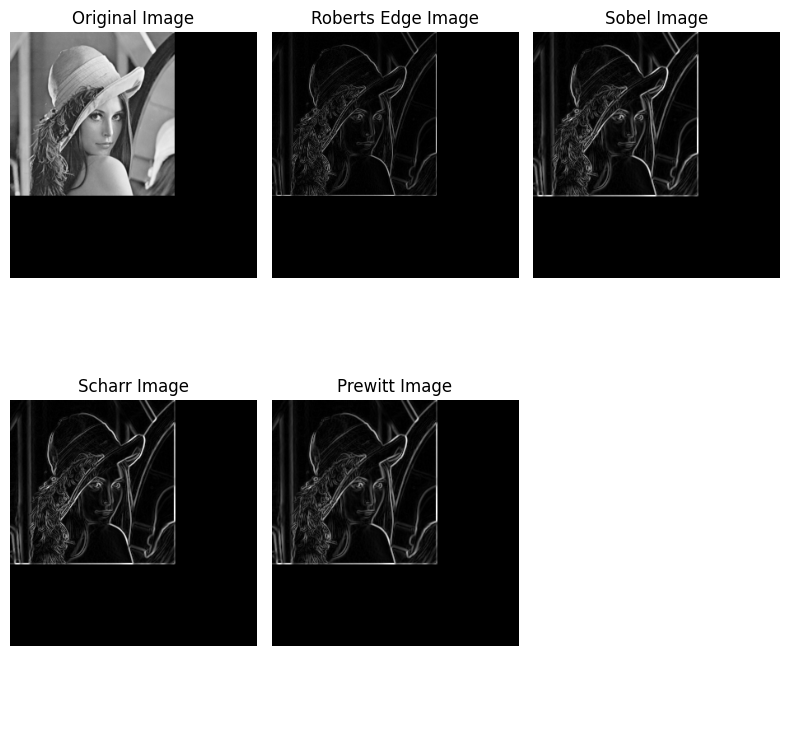

In [10]:
fig,axes = plt.subplots(nrows = 2 ,ncols =3,sharex = True,sharey=True,figsize = (8,8))
ax = axes.ravel()

ax[0].imshow(img1,cmap=plt.cm.gray)
ax[0].set_title("Original Image")

ax[1].imshow(edge_roberts,cmap=plt.cm.gray)
ax[1].set_title("Roberts Edge Image")

ax[2].imshow(edge_sobel,cmap=plt.cm.gray)
ax[2].set_title("Sobel Image")

ax[3].imshow(edge_scharr,cmap=plt.cm.gray)
ax[3].set_title("Scharr Image")

ax[4].imshow(edge_prewitt,cmap=plt.cm.gray)
ax[4].set_title("Prewitt Image")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()    

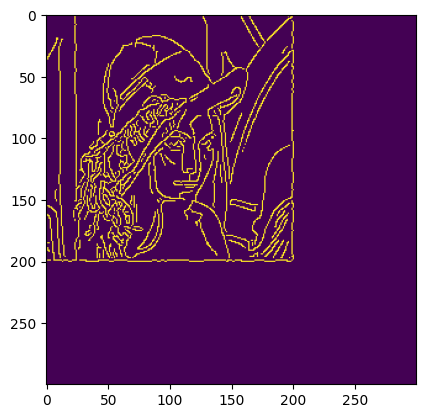

In [11]:
from skimage.feature import canny
edge_canny = canny(img1,sigma =1)
plt.imshow(edge_canny)
plt.show()

# De convulation

In [12]:
from skimage import restoration
import numpy as np
import scipy.stats as st

[[0.003765   0.015019   0.02379159 0.015019   0.003765  ]
 [0.015019   0.05991246 0.0949073  0.05991246 0.015019  ]
 [0.02379159 0.0949073  0.15034262 0.0949073  0.02379159]
 [0.015019   0.05991246 0.0949073  0.05991246 0.015019  ]
 [0.003765   0.015019   0.02379159 0.015019   0.003765  ]]


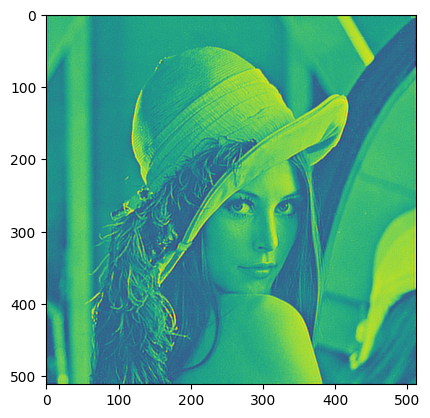

In [13]:
#define kernal
def gkern(kernalen =21,nsig= 2):
    lim = kernalen//2 + (kernalen % 2)/2
    x = np.linspace(-lim,lim,kernalen+1)
    kern1d = np.diff(st.norm.cdf(x))
    kern2d = np.outer(kern1d,kern1d)
    return kern2d/kern2d.sum()

psf = gkern(5,3)
print(psf)
deconvolved , _ = restoration.unsupervised_wiener(img,psf)
plt.imshow(deconvolved)
plt.show()



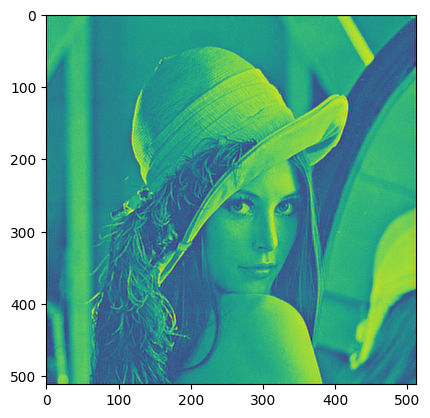

In [14]:

psf = np.ones((3,3))/9
deconvolved , _ = restoration.unsupervised_wiener(img,psf)
plt.imshow(deconvolved)
plt.show()

# **Scratch assay analysis**

In [ ]:
from skimage.filters.rank import entropy
from skimage.morphology import disk
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte 

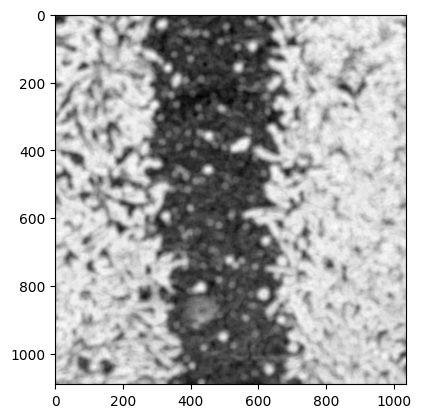

In [23]:
img = io.imread(r"E:\BDA\digital image processing\Practice_images\wound_img.jpg")
IMG_GRAY = img_as_ubyte(rgb2gray(img))
entr_img = entropy(IMG_GRAY,disk(10))
plt.imshow(entr_img,cmap="gray")

In [ ]:
from skimage.filters import try_all_threshold
fig,ax = try_all_threshold(entr_img,figsize=(10,8),verbo = False)
plt.show()

NameError: name 'entr_img' is not defined

4.7825331698510665


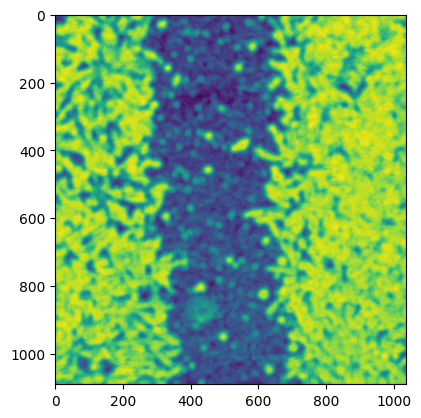

In [25]:
from skimage.filters import threshold_otsu
thresh = threshold_otsu(entr_img)
print(thresh)
plt.imshow(entr_img)

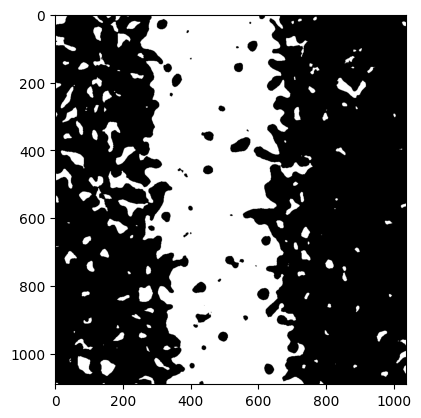

In [27]:
binary = entr_img <= thresh
plt.imshow(binary,cmap = "gray")


In [28]:
print(np.sum(binary == True))

411083


IMPORT IMAGES AND PLOT THEM

In [ ]:
import glob

time = 0
time_list = []
area_list = []
path = " "
for file in glob.glob(path):
    img = io.imread(file)
    entr_img = entropy(img,disk(10))
    thresh = threshold_otsu(entr_img)
    binary = entr_img <= thresh
    scratch_area = np.sum(binary == True)
    print(np.sum(binary == True))
    print(time,scratch_area)
    time_list.append(time)
    area_list.append(time)
    time += 1

print(time_list,area_list)
plt.plot(time_list,area_list,'bo')

from scipy.stats import linregress
slop,intercept,r_value,p_value,std_err = linregress(time_list,area_list)
print("y=",slop,"x=","+",intercept)
print("R**2",r_value**2)